In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_3562/2669226731.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic            

In [3]:
# (Optional) Rebuild preprocessed data from raw CSV

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), columns=cat_cols, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [7]:
# Step 2 — Split

from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric columns (fit on train only) — same as Class 2, trees don't
# strictly need this, but keeping it consistent with the preprocessed dataset.
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (5634, 30), Test shape: (1409, 30)


In [8]:
# =============================================================================
# TASK 2: Train a Decision Tree
# =============================================================================

# Step 1 — Train
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Step 2 — Evaluate
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree F1: {dt_f1:.4f}")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7410
Decision Tree F1: 0.5020
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1035
           1       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



In [9]:
# =============================================================================
# TASK 3: Train a Random Forest
# =============================================================================

# Step 1 — Train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Step 2 — Evaluate
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest F1: {rf_f1:.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7857
Random Forest F1: 0.5493
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



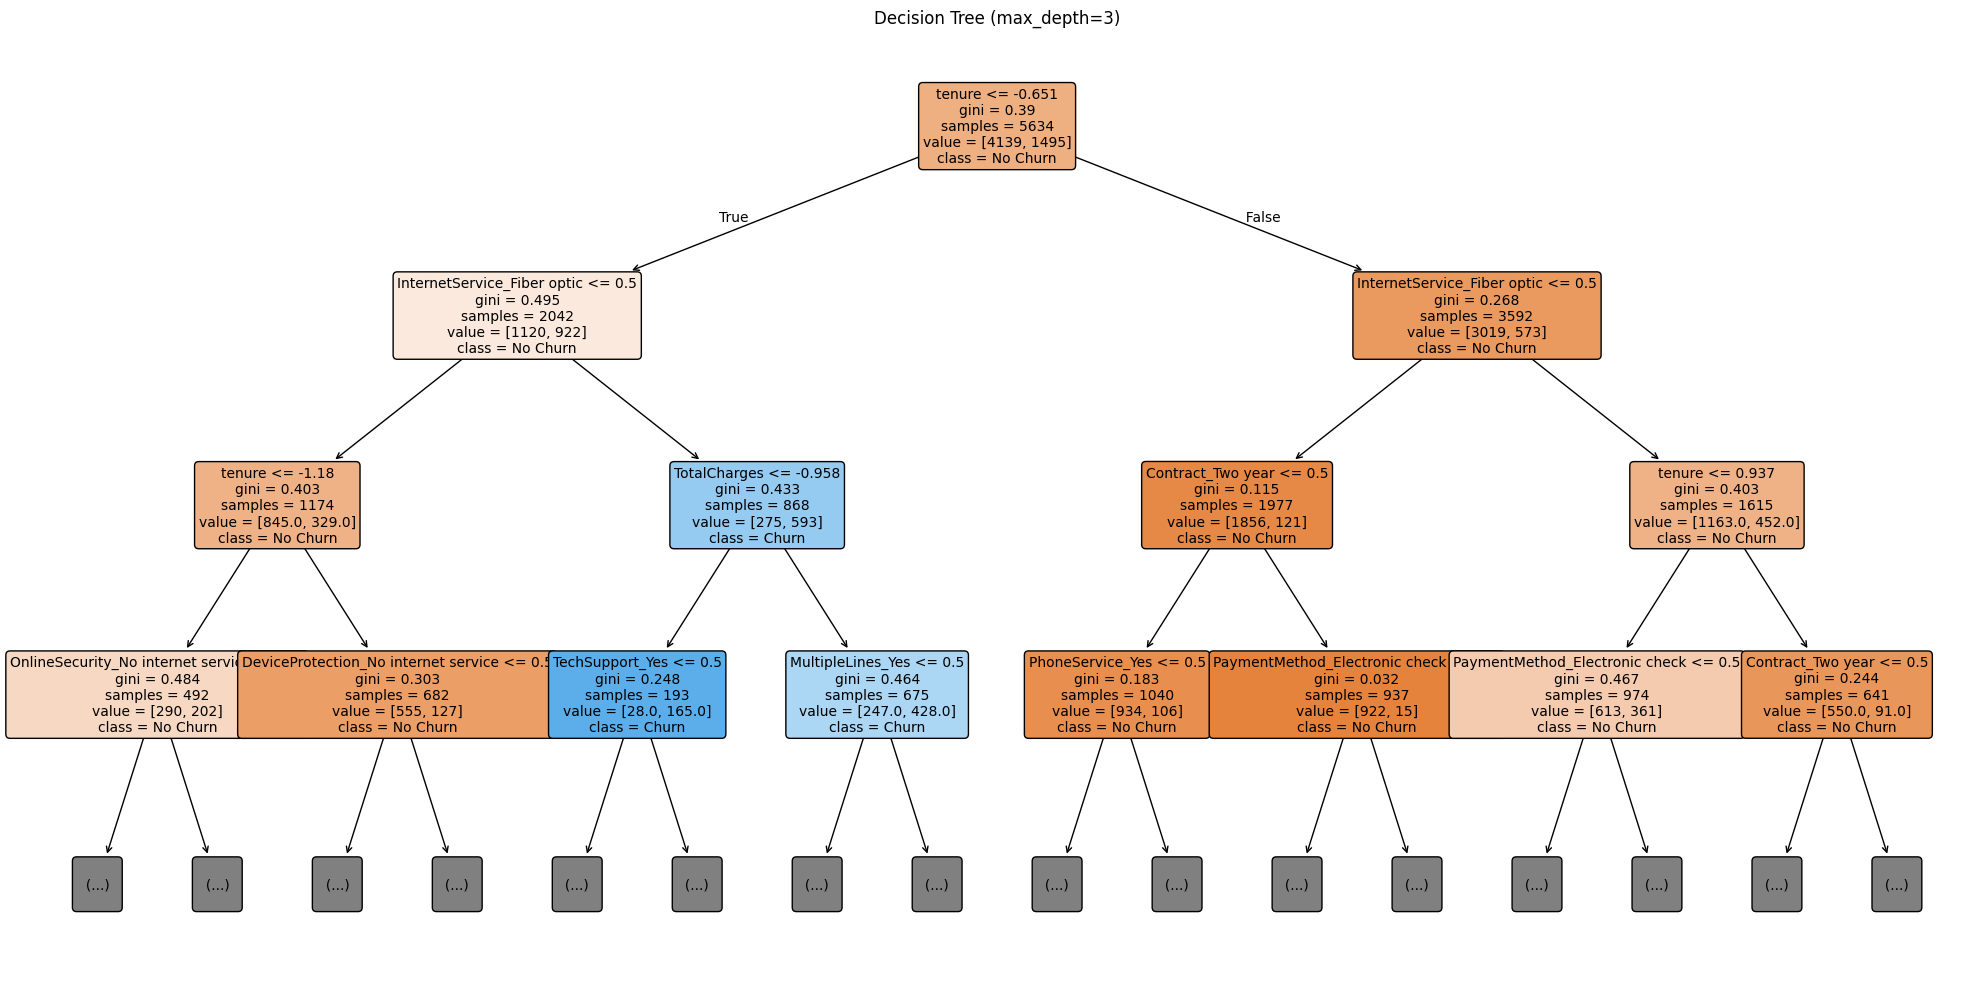

In [11]:
# =============================================================================
# TASK 4: Visualize the Decision Tree
# =============================================================================

# Step 1 — Plot with limited depth for readability
plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=3, filled=True, feature_names=X.columns,
          class_names=['No Churn', 'Churn'], fontsize=10, rounded=True)
plt.title('Decision Tree (max_depth=3)')
plt.tight_layout()
plt.show()

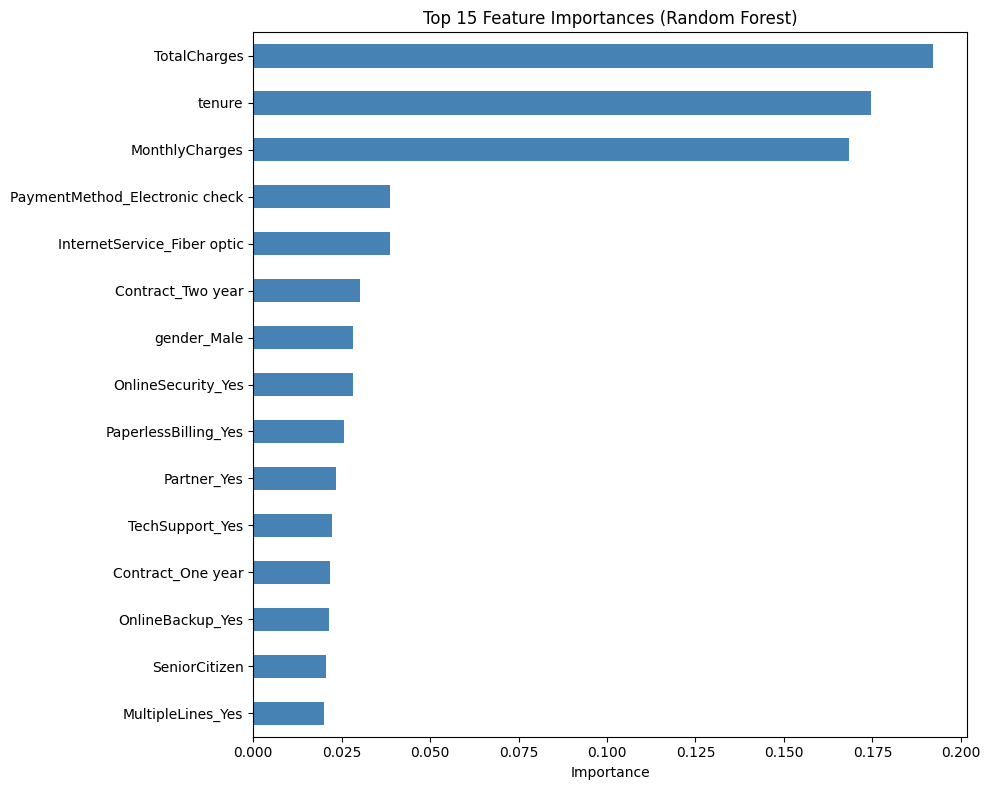

TotalCharges                      0.192096
tenure                            0.174733
MonthlyCharges                    0.168413
PaymentMethod_Electronic check    0.038771
InternetService_Fiber optic       0.038641
Contract_Two year                 0.030176
gender_Male                       0.028321
OnlineSecurity_Yes                0.028191
PaperlessBilling_Yes              0.025617
Partner_Yes                       0.023326
TechSupport_Yes                   0.022209
Contract_One year                 0.021710
OnlineBackup_Yes                  0.021431
SeniorCitizen                     0.020484
MultipleLines_Yes                 0.019969
dtype: float64


In [12]:
# =============================================================================
# TASK 5: Extract and Plot Feature Importances
# =============================================================================

# Step 1 — Extract importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_15 = importances.sort_values(ascending=True).tail(15)

# Step 2 — Plot as horizontal bar chart
top_15.plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(top_15.sort_values(ascending=False))

In [14]:
# =============================================================================
# TASK 6: Write a Comparison
# =============================================================================

# Step 1 — Summary table
summary_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_accuracy, rf_accuracy],
    'F1': [dt_f1, rf_f1]
})
summary_df

,Model,Accuracy,F1
0,Decision Tree,0.740951,0.502046
1,Random Forest,0.785664,0.549254
